In [25]:
import pandas as pd

In [26]:
df = pd.read_parquet('modelling_dataset.parquet')

In [27]:
df.head()

,Time_Stamp,Year,Hour,Day_of_Week,Month,Weekend,Holiday,Zone_Int_ID,Amenity,Crossing,...,Wind_Speed(mph),Precipitation(in),Weather_Clear,Weather_Cloudy,Weather_Dust/Windy,Weather_Rain/Drizzle,Weather_Snow/Ice,Weather_Stormy,Weather_Visibility Issues,Accident_Count
0,2016-06-14 20:00:00,2016,20,1,6,0,0,0,0.041169,0.233068,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,2016-06-14 20:00:00,2016,20,1,6,0,0,1,0.030181,0.424547,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2016-06-14 20:00:00,2016,20,1,6,0,0,2,0.000000,0.316667,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2016-06-14 20:00:00,2016,20,1,6,0,0,3,0.000000,0.161290,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2016-06-14 20:00:00,2016,20,1,6,0,0,4,0.000000,0.021277,...,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


# Approach

In this cell, I am employing a 2 Step Approach Using XGBoost

### Step 1: XGB Classifier

Train an XGBoost Classifier on a subsampled training set (1:5 accident to non-accident ratio) 
to predict a binary target: $0$ (No Accident) vs. $1$ (At least one accident)

### Step 2: XGB Regressor

Filter dataset to only include rows where Accident_Count > 0. Train an XGBoost Regressor 
on this subset to predict the expected severity. Target is log-transformed ($\log(1 + \text{count})$)  to handle extreme outliers (counts up to 105), then converted back

### Step 3: Adding Models Together

Model A gives $P(\text{Accident})$. Model B gives $E[\text{Count} \mid \text{Accident}]$. 
Multiply them together to get the final Expected Risk Score:

$$\text{Risk Score} = P(\text{Accident}) \times E[\text{Count} \mid \text{Accident}]$$

## STEP 1: XBG Classifier

In [28]:
# Creating a binary target variable for accident occurrence to use as target
df["Is_Accident"] = (df["Accident_Count"] > 0).astype(int)

In [29]:
# Looking at where to split the time series data for training, validation, and testing
split_70 = df['Time_Stamp'].quantile(0.70)
split_85 = df['Time_Stamp'].quantile(0.85)

print(f"70% split: {split_70}")
print(f"85% split: {split_85}")

70% split: 2021-03-16 12:00:00
85% split: 2022-03-23 10:00:00


In [30]:
# Creating the datasets for training, validation, and testing based on the time splits
train_df = df[df['Time_Stamp'] < split_70].copy()
val_df = df[(df['Time_Stamp'] >= split_70) & (df['Time_Stamp'] < split_85)].copy()
test_df = df[df['Time_Stamp'] >= split_85].copy()

# Verifying the sizes of the datasets
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Testing set size: {len(test_df)}")

Training set size: 3290824
Validation set size: 705154
Testing set size: 705312


In [31]:
import numpy as np

def engineer_features(df, zone_stats=None):
    df_eng = df.copy()
    
    # interaction features
    df_eng['Wind_x_Precip'] = df_eng['Wind_Speed(mph)'] * df_eng['Precipitation(in)']
    df_eng['Hour_x_Weekend'] = df_eng['Hour'] * df_eng['Weekend']
    df_eng['BadWeather'] = (df_eng['Weather_Rain/Drizzle'] + df_eng['Weather_Stormy'] + df_eng['Weather_Visibility Issues']).clip(0, 1)
    df_eng['BadWeather_x_Hour'] = df_eng['BadWeather'] * df_eng['Hour']
    
    # non-linear relationships
    df_eng['Hour_squared'] = df_eng['Hour'] ** 2
    df_eng['WindSpeed_squared'] = df_eng['Wind_Speed(mph)'] ** 2
    df_eng['Precip_squared'] = df_eng['Precipitation(in)'] ** 2
    
    # cyclic encoding that tells model that hour 23 and hour 0 are close together
    df_eng['Hour_sin'] = np.sin(2 * np.pi * df_eng['Hour'] / 24)
    df_eng['Hour_cos'] = np.cos(2 * np.pi * df_eng['Hour'] / 24)
    df_eng['Month_sin'] = np.sin(2 * np.pi * df_eng['Month'] / 12)
    df_eng['Month_cos'] = np.cos(2 * np.pi * df_eng['Month'] / 12)
    df_eng['DayOfWeek_sin'] = np.sin(2 * np.pi * df_eng['Day_of_Week'] / 7)
    df_eng['DayOfWeek_cos'] = np.cos(2 * np.pi * df_eng['Day_of_Week'] / 7)
    
    # zone stats: compute from training only, reuse for val/test
    if zone_stats is None:
        # only called when processing training data
        zone_stats = (df.groupby('Zone_Int_ID')['Accident_Count']
                        .agg(['mean', 'std', 'max'])
                        .reset_index())
        zone_stats.columns = ['Zone_Int_ID', 'Zone_Mean', 'Zone_Std', 'Zone_Max']
        zone_stats['Zone_Std'] = zone_stats['Zone_Std'].fillna(0)
    
    df_eng = df_eng.merge(zone_stats, on='Zone_Int_ID', how='left')
    
    return df_eng, zone_stats

In [32]:
# apply to training data first, this computes zone_stats from training only
train_df_eng, zone_stats = engineer_features(train_df)

# pass zone_stats into val and test
val_df_eng,  _ = engineer_features(val_df,  zone_stats=zone_stats)
test_df_eng, _ = engineer_features(test_df, zone_stats=zone_stats)

print("New columns added:", [c for c in train_df_eng.columns if c not in train_df.columns])

New columns added: ['Wind_x_Precip', 'Hour_x_Weekend', 'BadWeather', 'BadWeather_x_Hour', 'Hour_squared', 'WindSpeed_squared', 'Precip_squared', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Zone_Mean', 'Zone_Std', 'Zone_Max']


In [33]:
new_features = [
    'Wind_x_Precip', 'Hour_x_Weekend', 'BadWeather', 'BadWeather_x_Hour', 'Hour_squared', 'WindSpeed_squared', 'Precip_squared',
    'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Zone_Mean', 'Zone_Std', 'Zone_Max']

# base features
features = [
    'Hour', 'Day_of_Week', 'Month', 'Weekend', 'Holiday', 'Year', 'Zone_Int_ID', 'Amenity', 'Crossing', 'Give_Way', 'Junction',
    'Railway', 'Station', 'Stop', 'Traffic_Signal', 'City_Houston', 'City_Miami', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Clear', 'Weather_Cloudy', 'Weather_Dust/Windy',
    'Weather_Rain/Drizzle', 'Weather_Snow/Ice', 'Weather_Stormy', 'Weather_Visibility Issues'
]

# add engineered features on top
regressor_features = features + new_features

print(f"Total regressor features: {len(regressor_features)}")

Total regressor features: 46


In [34]:
# subsampling the training set to provide more balance to the classes for the classification model (not needed for regression)
accidents = train_df_eng[train_df_eng['Is_Accident'] == 1]
non_accidents = train_df_eng[train_df_eng['Is_Accident'] == 0]

non_accidents_sampled = non_accidents.sample(n=len(accidents) * 5, random_state=42)

train_subsampled = pd.concat([accidents, non_accidents_sampled]).sample(frac=1, random_state=42)

print(f"Subsampled training set size: {len(train_subsampled)}")

Subsampled training set size: 782226


In [35]:
# Zone_Mean, Zone_Std, Zone_Max ARE zone stats from Accident_Count
# but they're safe because engineer_features computed them from training data only
classifier_features = regressor_features

# created X and y for the training, validation, and test sets for classification model
X_train_classifier = train_subsampled[classifier_features]
y_train_classifier = train_subsampled['Is_Accident']

X_val_classifier = val_df_eng[classifier_features]
y_val_classifier = val_df_eng['Is_Accident']

X_test_classifier = test_df_eng[classifier_features]
y_test_classifier = test_df_eng['Is_Accident']

In [36]:
from xgboost import XGBClassifier

# Training the model on the subsetted training data
classifier_model = XGBClassifier(
    n_estimators=150, # number of trees to build
    learning_rate=0.05, # how much the model updates prediction
    max_depth=5, #max tree depth
    scale_pos_weight=5,  # model gives 5x more importance to unbalanced class
    objective='binary:logistic', # binary classification
    eval_metric='logloss', # log loss as error
    subsample=0.8, # model randomly samples 80% of train data for each tree
    colsample_bytree=0.8, # model randomly samples 80% of cols fir each tree
    random_state=42 
)

classifier_model.fit(X_train_classifier, y_train_classifier)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

# Evaluating the initial model on the validation set 
y_val_preds = classifier_model.predict(X_val_classifier)
y_val_pred_proba = classifier_model.predict_proba(X_val_classifier)[:, 1]

# Checking metrics
print("Classification Report:")
print(classification_report(y_val_classifier, y_val_preds))

print("Confusion Matrix:")
print(confusion_matrix(y_val_classifier, y_val_preds))

print(f"ROC AUC Score: {roc_auc_score(y_val_classifier, y_val_pred_proba):.4f}")

print(f"Average Precision Score: {average_precision_score(y_val_classifier, y_val_pred_proba)}")


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.69      0.82    665539
           1       0.15      0.92      0.26     39615

    accuracy                           0.71    705154
   macro avg       0.57      0.81      0.54    705154
weighted avg       0.95      0.71      0.79    705154

Confusion Matrix:
[[461547 203992]
 [  3077  36538]]
ROC AUC Score: 0.8888
Average Precision Score: 0.31312501991917346


In [38]:
import numpy as np
from sklearn.model_selection import GridSearchCV, PredefinedSplit

X_tuning_classifier = pd.concat([X_train_classifier, X_val_classifier])
y_tuning_classifier = pd.concat([y_train_classifier, y_val_classifier])

# Identifying which is used for training (-1) and which is used for validation(0)
split_index = np.full(X_tuning_classifier.shape[0], -1)
split_index[len(train_subsampled):] = 0
pds = PredefinedSplit(test_fold=split_index)

# Reduced parameter grid for faster tuning (16 combinations instead of 72)
param_grid = {
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 150],
    'scale_pos_weight': [5, 15],
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    cv=pds,
    scoring="average_precision",  
    verbose=3,
    n_jobs=4
)

grid_search.fit(X_tuning_classifier, y_tuning_classifier)

best_classifier = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 1 folds for each of 16 candidates, totalling 16 fits


python(54116) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54117) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54118) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54119) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CV 1/1] END learning_rate=0.05, max_depth=5, n_estimators=100, scale_pos_weight=5;, score=0.309 total time=  17.5s
[CV 1/1] END learning_rate=0.05, max_depth=5, n_estimators=100, scale_pos_weight=15;, score=0.319 total time=  17.7s
[CV 1/1] END learning_rate=0.05, max_depth=5, n_estimators=150, scale_pos_weight=5;, score=0.314 total time=  19.7s
[CV 1/1] END learning_rate=0.05, max_depth=5, n_estimators=150, scale_pos_weight=15;, score=0.323 total time=  19.8s
[CV 1/1] END learning_rate=0.05, max_depth=7, n_estimators=100, scale_pos_weight=5;, score=0.293 total time=  15.6s
[CV 1/1] END learning_rate=0.05, max_depth=7, n_estimators=100, scale_pos_weight=15;, score=0.301 total time=  15.6s
[CV 1/1] END learning_rate=0.05, max_depth=7, n_estimators=150, scale_pos_weight=5;, score=0.298 total time=  16.5s
[CV 1/1] END learning_rate=0.05, max_depth=7, n_estimators=150, scale_pos_weight=15;, score=0.310 total time=  16.5s
[CV 1/1] END learning_rate=0.1, max_depth=5, n_estimators=100, scale

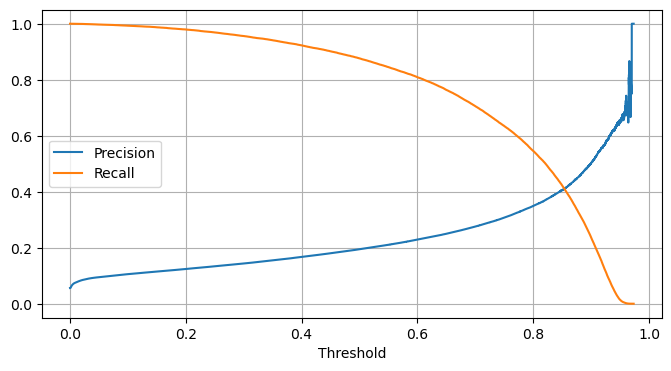

In [39]:
# Determining Optimal Threshold for Classification
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Using the best classifier on the validation set
y_val_probs = best_classifier.predict_proba(val_df_eng[regressor_features])[:, 1]
precision, recall, thresholds = precision_recall_curve(val_df_eng['Is_Accident'], y_val_probs)

# Plotting precision recall curve for visual analysis
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Testing final model on test dataset
y_test_pred_proba = best_classifier.predict_proba(X_test_classifier)[:, 1]

# Use a 0.3 threshold based on above precision-recall curve analysis 
y_test_preds = (y_test_pred_proba >= 0.4).astype(int)

# Checking metrics
print("Classification Report:")
print(classification_report(y_test_classifier, y_test_preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test_classifier, y_test_preds))

print(f"ROC AUC Score: {roc_auc_score(y_test_classifier, y_test_pred_proba):.4f}")

print(f"Average Precision Score: {average_precision_score(y_test_classifier, y_test_pred_proba)}")


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85    670990
           1       0.15      0.88      0.26     34322

    accuracy                           0.75    705312
   macro avg       0.57      0.81      0.55    705312
weighted avg       0.95      0.75      0.82    705312

Confusion Matrix:
[[499707 171283]
 [  4266  30056]]
ROC AUC Score: 0.8933
Average Precision Score: 0.32547594583908646


## STEP 2: XGB Regressor

In [41]:
# look at only accidents to train regression model (filter accident rows)
train_accidents = train_df_eng[train_df_eng['Is_Accident'] == 1].copy()
val_accidents = val_df_eng[val_df_eng['Is_Accident'] == 1].copy()

X_train_regressor = train_accidents[regressor_features]
y_train_regressor = train_accidents['Accident_Count'] # Use accident count as target for regression model

X_val_regressor = val_accidents[regressor_features]
y_val_regressor = val_accidents['Accident_Count']

# use log tranformations to remove large outliers
y_train_log = np.log1p(y_train_regressor) 
y_val_log = np.log1p(y_val_regressor)

# verification of regression datasets
print(f"Training on {len(X_train_regressor)} accident rows")
print(f"Validating on {len(X_val_regressor)} accident rows")

Training on 130371 accident rows
Validating on 39615 accident rows


In [42]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, PredefinedSplit

X_tuning_regressor = pd.concat([X_train_regressor, X_val_regressor]).reset_index(drop=True)
y_tuning_log = pd.concat([y_train_log, y_val_log]).reset_index(drop=True)

split_index = np.full(len(X_tuning_regressor), -1)
split_index[len(X_train_regressor):] = 0
pds = PredefinedSplit(test_fold=split_index)

# through trial and error this was the best set of parameters found for the regression model
param_grid_regressor = {
    'max_depth': [6],
    'learning_rate': [0.1],
    'n_estimators': [500],
    'subsample': [0.8],
    'colsample_bytree': [0.7],
    'min_child_weight': [1],
}

grid_search_regressor = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_grid_regressor,
    cv=pds,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

grid_search_regressor.fit(X_tuning_regressor, y_tuning_log)
best_regressor = grid_search_regressor.best_estimator_
print(f"Best Parameters: {grid_search_regressor.best_params_}")

Fitting 1 folds for each of 1 candidates, totalling 1 fits


python(54155) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54156) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54157) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54158) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54159) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54160) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54161) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(54162) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}


In [43]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

y_val_log_preds   = best_regressor.predict(val_accidents[regressor_features])
y_val_final_preds = np.expm1(y_val_log_preds)

mae = mean_absolute_error(y_val_regressor, y_val_final_preds)
rmse = root_mean_squared_error(y_val_regressor, y_val_final_preds)
r2_raw = r2_score(y_val_regressor, y_val_final_preds)
r2_log = r2_score(y_val_log, y_val_log_preds)  # what model actually optimized

print(f"MAE: {round(mae, 4)}")
print(f"RMSE: {round(rmse, 4)}")
print(f"R² (raw): {round(r2_raw, 4)}")
print(f"R² (log space): {round(r2_log, 4)}")

MAE: 1.2466
RMSE: 3.2449
R² (raw): 0.3189
R² (log space): 0.478


## STEP 3: Final Synthesis

In [44]:
# # Using the classifier to predict the probability of accident on test
# test_probs = best_classifier.predict_proba(X_test_classifier)[:, 1]
# test_preds = (test_probs >= 0.4).astype(int)

# # Using the regressor to predict the number of accidents on test
# test_log_severity = best_regressor.predict(X_test_classifier)
# test_severity = np.expm1(test_log_severity)


# final_results = test_df.copy() 
# final_results['Prob_Accident'] = test_probs
# final_results['Predicted_Accident'] = test_preds
# final_results['Expected_Severity'] = test_severity

# # Creating the final risk score by multiplying the probability of an accident occurring with the expected number of accidents
# final_results['Risk_Score'] = test_probs * test_severity
# final_results["Risk_Score_2"] = test_preds * test_severity

In [45]:
# using the classifier to predict the probability of accident on test
test_probs = best_classifier.predict_proba(X_test_classifier)[:, 1]
test_preds = (test_probs >= 0.4).astype(int)

# filter test set to only accident cases for regression
test_accidents = test_df_eng[test_df_eng['Is_Accident'] == 1].copy()
X_test_accidents = test_accidents[regressor_features]

# using the regressor to predict severity only on accident cases
test_log_severity_accidents = best_regressor.predict(X_test_accidents)
test_severity_accidents = np.expm1(test_log_severity_accidents)

# Initialize severity array with zeros for all test cases
test_severity = np.zeros(len(test_df_eng))
# Fill in severity predictions only for accident rows
accident_indices = test_df_eng[test_df_eng['Is_Accident'] == 1].index
test_severity[test_df_eng.index.isin(accident_indices)] = test_severity_accidents

final_results = test_df_eng.copy() 
final_results['Prob_Accident'] = test_probs
final_results['Predicted_Accident'] = test_preds
final_results['Expected_Severity'] = test_severity

# Creating the final risk score by multiplying the probability of an accident occurring with the expected number of accidents
final_results['Risk_Score'] = test_probs * test_severity
final_results["Risk_Score_2"] = test_preds * test_severity


In [46]:
final_results[final_results['Accident_Count'] > 1]

,Time_Stamp,Year,Hour,Day_of_Week,Month,Weekend,Holiday,Zone_Int_ID,Amenity,Crossing,...,DayOfWeek_sin,DayOfWeek_cos,Zone_Mean,Zone_Std,Zone_Max,Prob_Accident,Predicted_Accident,Expected_Severity,Risk_Score,Risk_Score_2
0,2022-03-23 10:00:00,2022,10,2,3,0,0,0,0.034011,0.188304,...,0.974928,-0.222521,0.567745,1.064073,9,0.929291,1,1.569974,1.458962,1.569974
185,2022-03-23 14:00:00,2022,14,2,3,0,0,9,0.004860,0.053463,...,0.974928,-0.222521,0.192961,0.523583,7,0.827457,1,1.228485,1.016518,1.228485
268,2022-03-23 16:00:00,2022,16,2,3,0,0,4,0.000000,0.015075,...,0.974928,-0.222521,0.057615,0.263937,5,0.647756,1,1.142486,0.740052,1.142486
269,2022-03-23 16:00:00,2022,16,2,3,0,0,5,0.008418,0.117845,...,0.974928,-0.222521,0.141876,0.431941,6,0.840795,1,1.561953,1.313282,1.561953
270,2022-03-23 16:00:00,2022,16,2,3,0,0,6,0.033071,0.212073,...,0.974928,-0.222521,0.347321,0.769599,13,0.933886,1,2.034831,1.900300,2.034831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678234,2023-02-26 04:00:00,2023,4,6,2,1,0,100,0.021277,0.095745,...,-0.781831,0.623490,0.112061,0.449839,12,0.364361,0,1.318182,0.480294,0.000000
678292,2023-02-26 06:00:00,2023,6,6,2,1,0,88,0.002304,0.057604,...,-0.781831,0.623490,0.381794,1.187958,71,0.797230,1,1.492794,1.190100,1.492794
678650,2023-02-26 16:00:00,2023,16,6,2,1,0,96,0.006897,0.224138,...,-0.781831,0.623490,0.268197,1.312758,105,0.826348,1,1.516406,1.253079,1.516406
678794,2023-02-26 20:00:00,2023,20,6,2,1,0,100,0.021277,0.095745,...,-0.781831,0.623490,0.112061,0.449839,12,0.657303,1,1.138991,0.748662,1.138991


## STEP 4: Visualizing Results

#### Looking at the actual accidents in the test set

In [47]:
import plotly.express as px
import h3

# Aggregate actual accident counts from test set by zone
miami_test = final_results[final_results['City_Miami'] == 1].copy()

zone_accidents = miami_test.groupby('Zone_ID')['Accident_Count'].sum().reset_index()
zone_accidents.rename(columns={'Accident_Count': 'Total_Accidents'}, inplace=True)

# Build GeoJSON from H3 zone IDs
geojson_features = []
for zone in zone_accidents['Zone_ID']:
    boundary = h3.cell_to_boundary(zone)
    coords = [[lon, lat] for lat, lon in boundary]
    coords.append(coords[0])
    geojson_features.append({
        'type': 'Feature',
        'id': zone,
        'properties': {},
        'geometry': {'type': 'Polygon', 'coordinates': [coords]}
    })

geojson = {'type': 'FeatureCollection', 'features': geojson_features}

# Plot the map
fig = px.choropleth_map(
    zone_accidents,
    geojson=geojson,
    locations='Zone_ID',
    featureidkey='id',
    color='Total_Accidents',
    color_continuous_scale='Reds',
    map_style='carto-positron',
    zoom=10,
    #center={'lat': 29.7604, 'lon': -95.3698},
    center={'lat': 25.7617, 'lon': -80.1918}, #for Miami
    title='Test Set: Actual Accident Counts by Zone',
    labels={'Total_Accidents': 'Accidents'}
)

fig.update_layout(margin={'r': 0, 't': 30, 'l': 0, 'b': 0})
fig.show()

In [48]:
import plotly.express as px
import h3

# Aggregate predicted risk scores from test set by zone
miami_test = final_results[final_results['City_Miami'] == 1].copy()

zone_risk = miami_test.groupby('Zone_ID')['Risk_Score'].sum().reset_index()
zone_risk.rename(columns={'Risk_Score': 'Total_Risk_Score'}, inplace=True)

# Build GeoJSON from H3 zone IDs
features = []
for zone in zone_risk['Zone_ID']:
    boundary = h3.cell_to_boundary(zone)
    coords = [[lon, lat] for lat, lon in boundary]
    coords.append(coords[0])
    features.append({
        'type': 'Feature',
        'id': zone,
        'properties': {},
        'geometry': {'type': 'Polygon', 'coordinates': [coords]}
    })

geojson = {'type': 'FeatureCollection', 'features': features}

# Plot the map
fig = px.choropleth_map(
    zone_risk,
    geojson=geojson,
    locations='Zone_ID',
    featureidkey='id',
    color='Total_Risk_Score',
    color_continuous_scale='Reds',
    map_style='carto-positron',
    zoom=10,
    #center={'lat': 29.7604, 'lon': -95.3698},
    center={'lat': 25.7617, 'lon': -80.1918}, #for Miami
    title='Test Set: Predicted Risk Score by Zone',
    labels={'Total_Risk_Score': 'Risk Score'}
)

fig.update_layout(margin={'r': 0, 't': 30, 'l': 0, 'b': 0})
fig.show()

In [50]:
# Having the models saved for reproducibility and future use without needing to retrain

import joblib

joblib.dump(best_classifier, 'xgb_classifier_model.pkl')
joblib.dump(best_regressor, 'xgb_regressor_model.pkl')

['xgb_regressor_model.pkl']